[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_1_Intro.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# Initial LSDB: Gaia DR3 HR Diagram

In this notebook we'll show how to:
- Import a Dask client
- Load the Gaia DR3 catalog (lazily) from cloud storage
- Understand HATS partitioning
- Filter for well-measured parallaxes and plot a Hertzsprung-Russell diagram
- Save the results to disk

In [1]:
# # do you need to install the package?
# # if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb s3fs

In [2]:
# Standard library imports
import logging
import os
import warnings

# Must be set before importing packages that use numexpr
os.environ["NUMEXPR_MAX_THREADS"] = "2"

# Third-party imports
import dask
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from dask.distributed import Client
from lsdb import ConeSearch
from matplotlib import rcParams

# Jupyter magic commands
%matplotlib inline

# Configuration
warnings.simplefilter("ignore")
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 550
rcParams["font.size"] = 20
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 2
dask.config.set({"dataframe.convert-string": False})

print(f"Version of lsdb is {lsdb.__version__}")

Version of lsdb is 0.9.2


## Setup Dask cluster

LSDB uses the Dask framework for parallel and out-of-memory computing. Dask is a flexible library for parallel computing in Python that scales from single machines to large clusters. When using LSDB, it is usually worth setting up a Dask cluster (local or multi-node) to take advantage of parallel computing. With no Dask cluster, LSDB would use a single CPU core for the computations, which is prohibitive for large datasets.

In [3]:
client = Client(n_workers=2, memory_limit="4GiB", threads_per_worker=1)

# Print the dashboard link and port
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:8787/status


We'll use the Gaia DR3 catalog, loaded directly from a public cloud bucket. Other versions and distributions of Gaia DR3 are available; see the [data.lsdb.io Gaia DR3 page](https://data.lsdb.io/Gaia/Gaia_DR3_(US-East%2C_S3)) for a full list.

Let's open a HATS-formatted catalog with `lsdb.open_catalog()`. We'll use Gaia DR3, passing the URL to a public S3 bucket. We also specify only the columns we need: loading fewer columns is important for performance when working with large catalogs.

In [4]:
# Gaia DR3 at STScI public bucket
gaia_path = "s3://stpubdata/gaia/gaia_dr3/public/hats"

In [5]:
gaia_catalog = lsdb.open_catalog(
    gaia_path,
    # coordinate columns are always loaded
    columns=["source_id", "parallax", "parallax_over_error", "phot_g_mean_mag", "bp_rp"],
)
gaia_catalog

,source_id,parallax,parallax_over_error,phot_g_mean_mag,bp_rp,ra,dec
npartitions=2016,,,,,,,
"Order: 2, Pixel: 0",int64[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 2, Pixel: 1",...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...,...


We've specified only the columns needed for our science case. This matters for performance: without an explicit column list, all ~150 Gaia DR3 columns would be loaded when the workflow runs, which is much slower and uses far more memory.

Some catalogs define a default set of columns that are loaded if you don't specify your own, to avoid accidental I/O overload. You can always inspect the full available column list with `catalog.all_columns`.

In [6]:
gaia_catalog.all_columns

['solution_id',
 'designation',
 'source_id',
 'random_index',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'ra_dec_corr',
 'ra_parallax_corr',
 'ra_pmra_corr',
 'ra_pmdec_corr',
 'dec_parallax_corr',
 'dec_pmra_corr',
 'dec_pmdec_corr',
 'parallax_pmra_corr',
 'parallax_pmdec_corr',
 'pmra_pmdec_corr',
 'astrometric_n_obs_al',
 'astrometric_n_obs_ac',
 'astrometric_n_good_obs_al',
 'astrometric_n_bad_obs_al',
 'astrometric_gof_al',
 'astrometric_chi2_al',
 'astrometric_excess_noise',
 'astrometric_excess_noise_sig',
 'astrometric_params_solved',
 'astrometric_primary_flag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'pseudocolour_error',
 'ra_pseudocolour_corr',
 'dec_pseudocolour_corr',
 'parallax_pseudocolour_corr',
 'pmra_pseudocolour_corr',
 'pmdec_pseudocolour_corr',
 'astrometric_matched_transits',
 'visibility_periods_used',
 'astrometric_sigma5d_max

## Lazy Operations

When working with large datasets, there is too much data to be loaded into memory at once. To get around this, LSDB uses the HATS format which partitions a catalog into HEALPix tiles and works on one partition at a time. This also allows the computation to be parallelized to work on multiple partitions at once. In order to efficiently carry out pipelines of operations though, it's better to batch operations so that multiple operations can be done back to back on the same partition instead of having to load and save each partition from storage after every operation.

For this reason, operations in LSDB are performed 'lazily'. This means when a catalog is read using `open_catalog`, the actual catalog data isn't being read from storage. Instead, it only loads the metadata such as the column schema and the HEALPix structure of the partitions. When an operation like `cone_search` is called on a catalog, the data is not actually loaded and operated on when the line of code is executed. Instead, the catalog keeps track of the operations that it needs to perform so the entire pipeline can be efficiently run later. This also allows us to optimize the pipeline by only loading the partitions that are necessary. For example when performing a cone search like we do here, we only need the partitions that have data within the cone.

![lazy loading diagram](https://raw.githubusercontent.com/astronomy-commons/lsdb/main/docs/_static/lazy_diagram.svg)

So when we look at a catalog that has been lazy loaded we see the DataFrame without the data, just the columns and the number of partitions (including the HATS index of each partition encoding which HEALPix cell the partition is in). 

In [7]:
# 5-degree cone
ra_center, dec_center, radius_deg = 150.0, 30.0, 5.0
cone_search = ConeSearch(ra=ra_center, dec=dec_center, radius_arcsec=radius_deg * 3600)

# Full set of columns needed for the HR diagram
gaia_cone = lsdb.open_catalog(
    gaia_path,
    columns=["source_id", "ra", "dec", "parallax", "parallax_over_error", "phot_g_mean_mag", "bp_rp"],
    search_filter=cone_search,
)

To load the data and perform the operations, call compute() which will load the necessary data and perform all the operations that have been called, and return a Pandas DataFrame with the results.

In [8]:
# around 10 seconds expected
gaia_cone_computed = gaia_cone.compute()

The result is a pandas DataFrame with the filtered stars.

In [9]:
gaia_cone_computed

,source_id,ra,dec,parallax,parallax_over_error,phot_g_mean_mag,bp_rp
_healpix_29,,,,,,,
321299130938838899,642598236435408896,151.010353,25.082803,<NA>,<NA>,16.36272,<NA>
321299130949825410,642598232140438016,151.010126,25.08314,2.99009,134.039444,11.299402,0.765597
...,...,...,...,...,...,...,...
398024589230763205,796049171587537920,148.147851,34.737151,1.957024,75.212227,14.864364,1.247128
398024622441128264,796049240307659904,148.133669,34.744793,-0.768419,-1.369282,20.217165,0.761408


## HATS (Hierarchical Adaptive Tiling Scheme) Partitioning

To make parallel computation efficient, HATS partitions contain roughly the same number of rows. This is achieved by using different HEALPix pixel sizes across the sky depending on source density; denser regions of the sky get smaller pixels. We can visualise the pixel layout of our catalog with `plot_pixels()`.

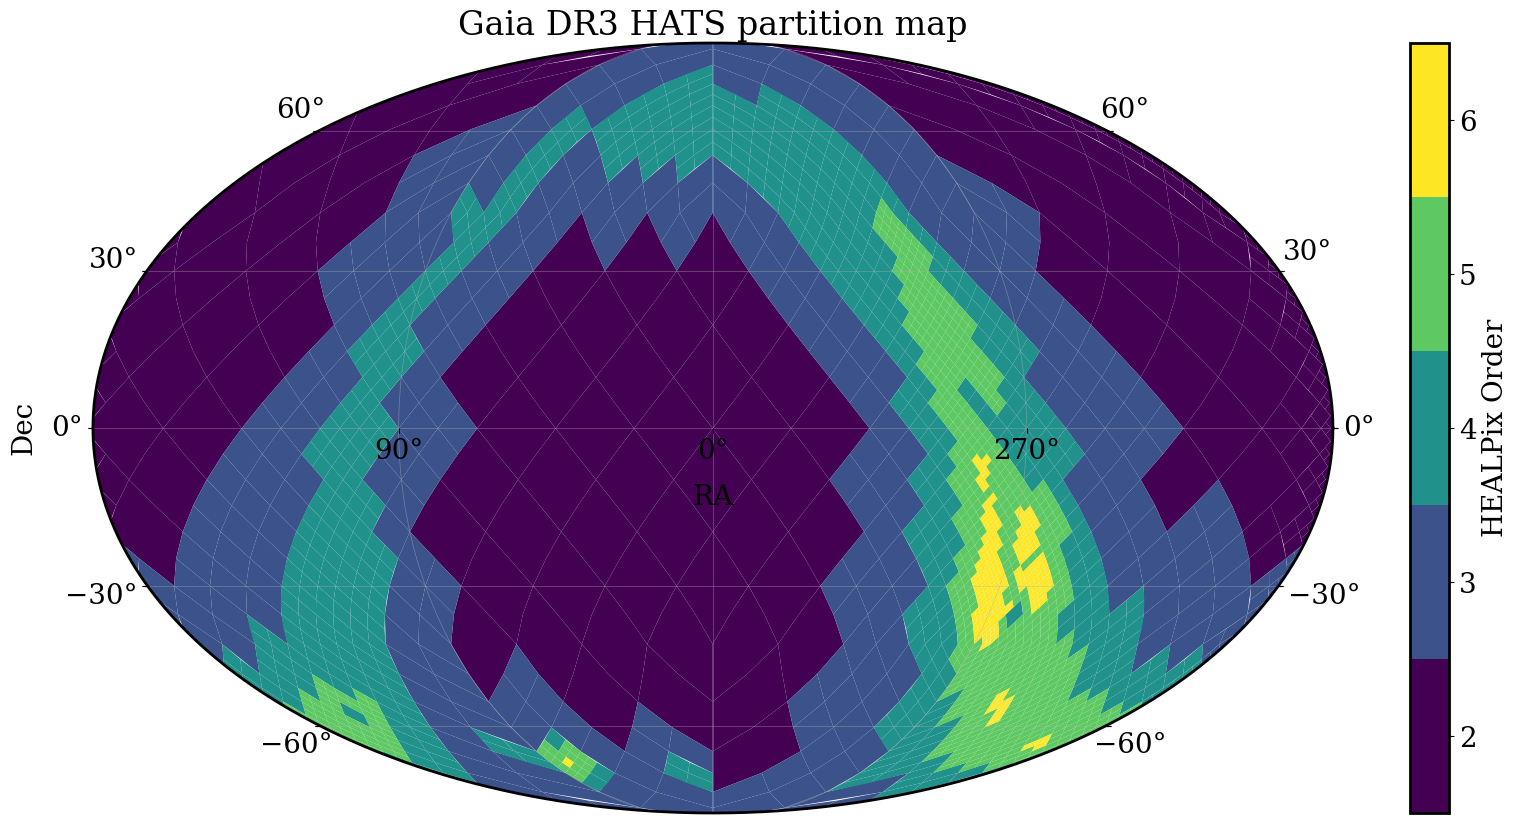

In [10]:
fig = plt.figure(figsize=(20, 10))
gaia_catalog.plot_pixels(fig=fig)
plt.title("Gaia DR3 HATS partition map")
plt.show()

## Hertzsprung-Russell Diagram

We now compute the cone search result and build an HR diagram. We keep only stars with `parallax_over_error > 30`, a quality cut that ensures the parallax (and therefore the distance) is well measured. The absolute magnitude is then computed from the apparent G magnitude and the parallax:

$$G_\mathrm{abs} = G + 5\log_{10}(\varpi) - 10$$

where $\varpi$ is the parallax in milliarcseconds.

In [11]:
%%time
# Filter lazily, then compute
gaia_hr_catalog = gaia_cone.query("parallax_over_error > 30 and parallax > 0")
gaia_hr = gaia_hr_catalog.compute()
print(f"Stars with parallax_over_error > 30: {len(gaia_hr):,}")

Stars with parallax_over_error > 30: 21,498
CPU times: user 363 ms, sys: 127 ms, total: 489 ms
Wall time: 17.5 s


In [12]:
# Absolute G magnitude from parallax (in mas)
gaia_hr["G_abs"] = gaia_hr["phot_g_mean_mag"] + 5 * np.log10(gaia_hr["parallax"]) - 10
gaia_hr.head()

,source_id,ra,dec,parallax,parallax_over_error,phot_g_mean_mag,bp_rp,G_abs
_healpix_29,,,,,,,,
321299130949825410,642598232140438016,151.010126,25.08314,2.99009,134.039444,11.299402,0.765597,3.677823
321300926854107832,642601844207943168,151.307094,25.148742,0.800249,31.558275,14.689921,0.853265,4.206048
321301055591462768,642602084726115584,151.226284,25.122636,1.792571,78.721512,14.262867,1.045634,5.530249
321302063756194246,642604107655698816,151.048248,25.096865,1.239015,68.637154,12.555639,1.086869,3.021022
321302812099755883,642605623779157376,151.179879,25.173313,0.969426,53.207466,13.57333,1.238965,3.505904


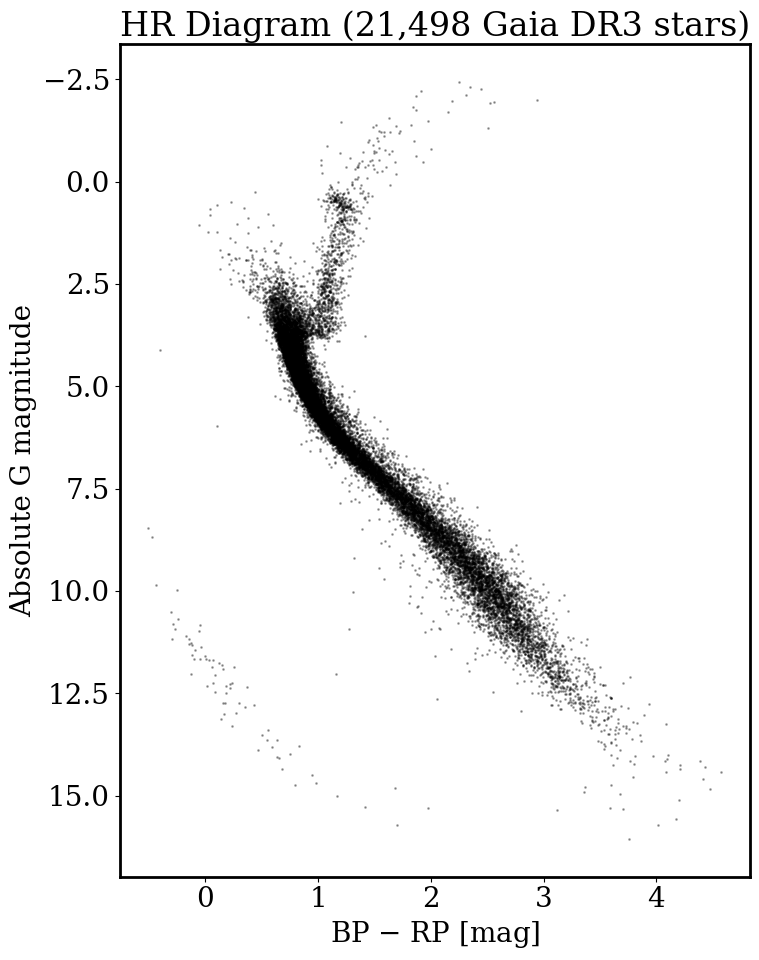

In [13]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(gaia_hr["bp_rp"], gaia_hr["G_abs"], s=1, alpha=0.3, color="black", rasterized=True)
ax.set_xlabel("BP $-$ RP [mag]")
ax.set_ylabel("Absolute G magnitude")
ax.set_title(
    f"HR Diagram ({len(gaia_hr):,} Gaia DR3 stars)"
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Export results to disk

Once an analysis is complete we can save the results. Here we export the filtered Gaia sample in HATS format under `hats/`. You can reload it later with any parquet reader, or re-open it as a HATS catalog with LSDB.

In [14]:
# Export the filtered catalog to disk in HATS format
gaia_hr_catalog.write_catalog("hats/gaia_hr_sample")

In [15]:
client.close()

## Problem 1

## Color-Magnitude Diagram of the h and χ Persei Double Cluster

The h and χ Persei double cluster (NGC 869 and NGC 884) is a pair of young open clusters at ~2.3 kpc, both visible to the naked eye in Perseus. Because the member stars are all at roughly the same distance and share a common proper motion, they stand out clearly as overdensities in proper-motion and parallax space.

**Your task:** isolate the cluster members from the Milky Way field and plot their color-magnitude diagram.

**Steps:**
1. Load Gaia DR3 in a 1-degree cone around RA = 34.9 deg, Dec = +57.1 deg. Include `phot_g_mean_mag`, `bp_rp`, `parallax`, `pmra`, and `pmdec`. Compute the result.
2. Plot histograms of `pmra`, `pmdec`, and `parallax`. You should see a clear overdensity from the cluster on top of the smooth Milky Way background.
3. Select cluster members by cutting on those three quantities around the overdensity peaks.
4. Plot apparent G magnitude (y-axis, inverted) vs BP-RP color (x-axis). You should see a clean young main sequence and, if your cuts are tight enough, the two clusters may even separate slightly.

**Advanced:** instead of computing first and histogramming the pandas dataframe, try to compute the histograms lazily directly on the LSDB catalog. See the [LSDB plotting tutorial](https://docs.lsdb.io/en/latest/tutorials/pre_executed/plotting.html#7.2-Across-the-Sky) for an example.

One possible solution is in `Notebook_1_Solution.ipynb`.